# Finalised GFC Analysis

# Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")

# Slide 3: Early Signs of Stress

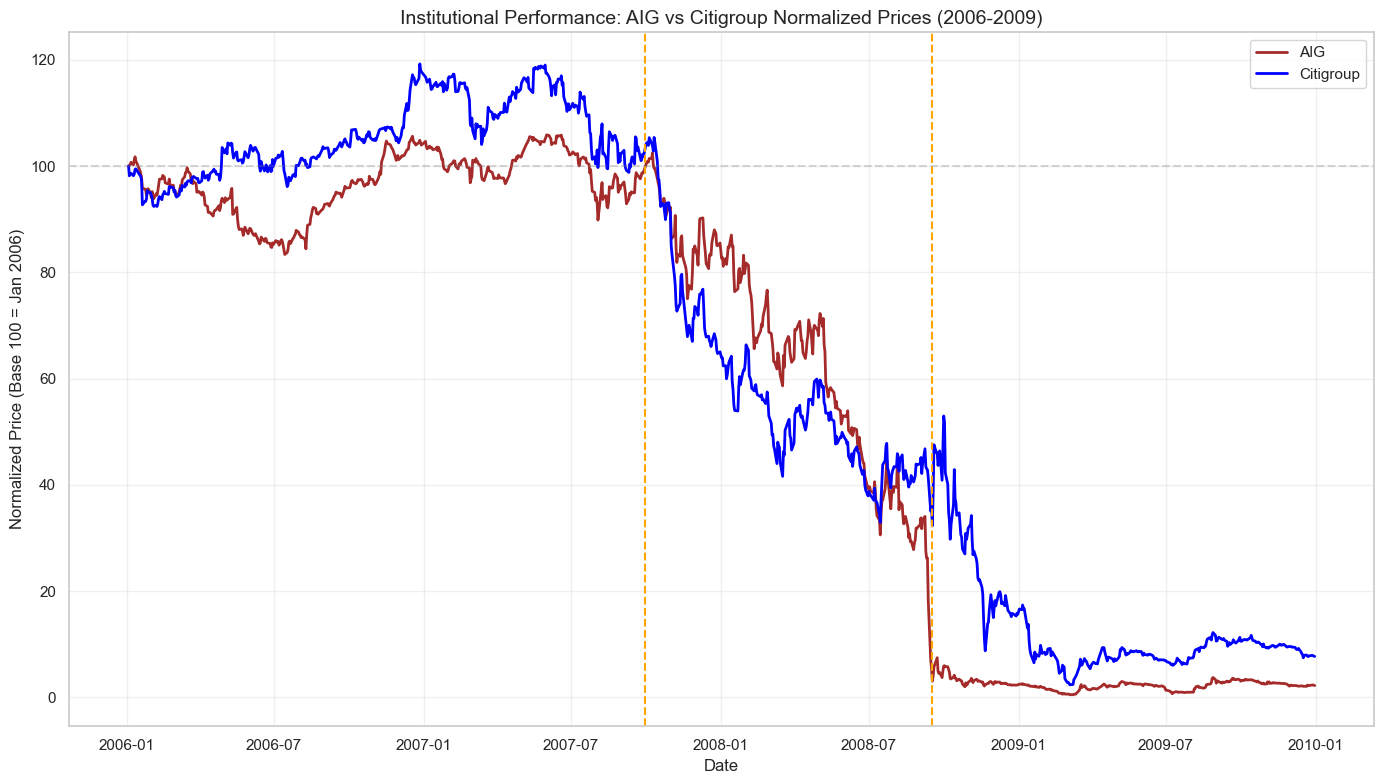

In [2]:
def load_gfc_df(filepath):
    df = pd.read_csv(filepath, skiprows=3, names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'])
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.set_index('Date')
    for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.loc['2006-01-01':'2009-12-31']
def get_normalized_series(series):
    return (series / series.iloc[0]) * 100
# 1. Load and normalize data
aig = load_gfc_df("../data/AIG.csv")
c_stock = load_gfc_df("../data/C.csv")
aig_norm = get_normalized_series(aig['Close'])
c_norm = get_normalized_series(c_stock['Close'])
# 3. Create the Plot
plt.figure(figsize=(14, 8))
plt.plot(aig_norm, label='AIG (Normalized)', color='brown', linewidth=2)
plt.plot(c_norm, label='Citigroup (Normalized)', color='blue', linewidth=2)
# 5. Add Vertical Lines for Key Timeline Dates
dates = {
    '2007-09-30': 'Early Crisis Path\n(Sept 2007)',
    '2008-09-16': 'Lehman/AIG Crisis\n(Sept 16, 2008)'
}
for d_str, label in dates.items():
    d = pd.to_datetime(d_str)
    plt.axvline(x=d, color='orange', linestyle='--', linewidth=1.5)
# Formatting
plt.title('Institutional Performance: AIG vs Citigroup Normalized Prices (2006-2009)', fontsize=14)
plt.ylabel('Normalized Price (Base 100 = Jan 2006)')
plt.xlabel('Date')
plt.legend(['AIG', 'Citigroup'])
plt.grid(True, alpha=0.3)
plt.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Slide 4: How Panic Propagates

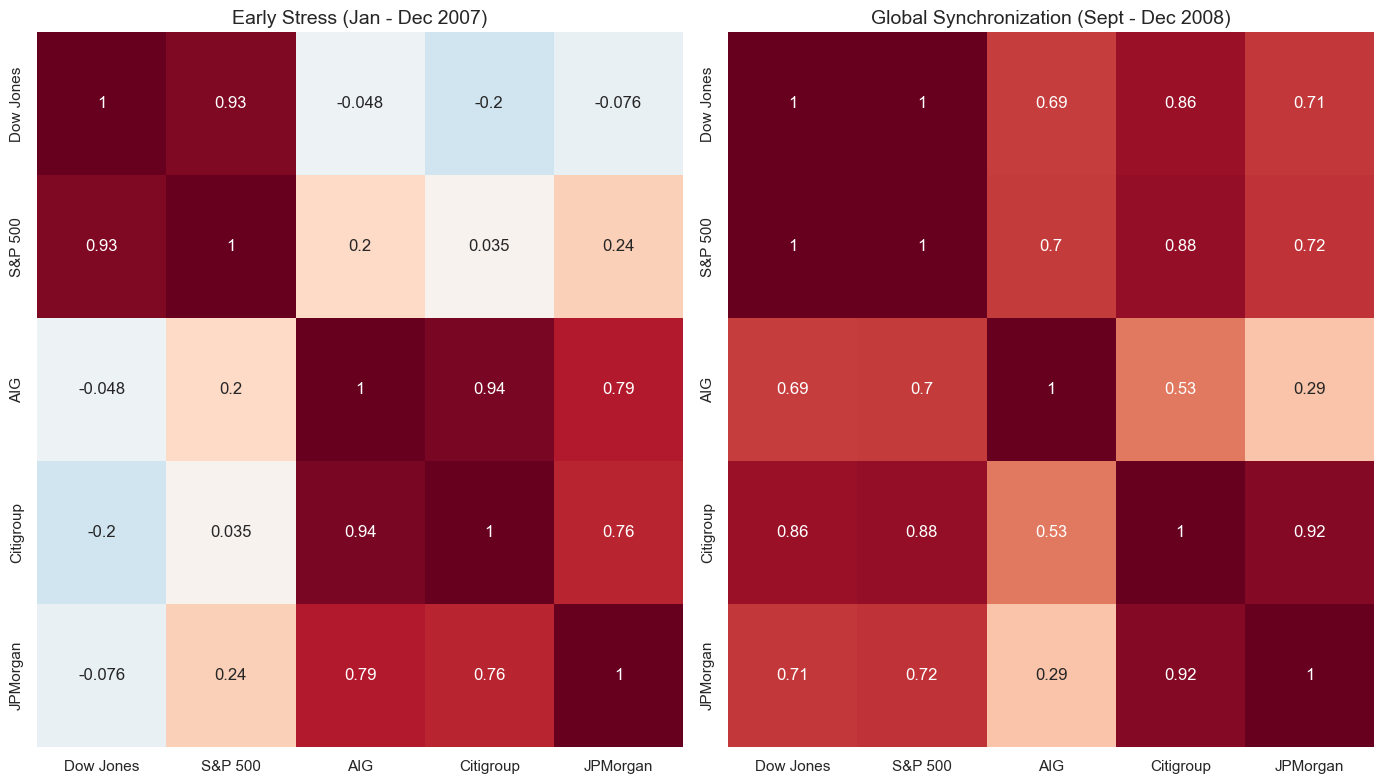

In [3]:
# Load TED Rate and DJI for the heatmap
tedrate = pd.read_csv("../data/TEDRATE.csv", na_values='.')
tedrate['observation_date'] = pd.to_datetime(tedrate['observation_date'])
tedrate = tedrate.set_index('observation_date')

vix = load_gfc_df("../data/^VIX.csv")
vix_clean = vix['Close'].to_frame('VIX')
dji = load_gfc_df("../data/^DJI.csv")
gspc = load_gfc_df("../data/^GSPC.csv")
aig = load_gfc_df("../data/AIG.csv")
c_stock = load_gfc_df("../data/C.csv")
jpm = load_gfc_df("../data/JPM.csv")

# Create a combined dataframe for cross-asset analysis
combined = pd.concat([
    dji['Close'].to_frame('Dow Jones'),
    gspc['Close'].to_frame('S&P 500'),
    aig['Close'].to_frame('AIG'),
    c_stock['Close'].to_frame('Citigroup'),
    jpm['Close'].to_frame('JPMorgan')
], axis=1).dropna()

# Define calculation windows
windows = {
    "Early Stress (Jan - Dec 2007)": ('2007-01-01', '2007-12-31'),
    "Global Synchronization (Sept - Dec 2008)": ('2008-09-01', '2008-12-31')
}

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for i, (title, (start, end)) in enumerate(windows.items()):
    corr = combined.loc[start:end].corr()
    sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, ax=axes[i], cbar=(i == 2))
    axes[i].set_title(title, fontsize=14)

plt.tight_layout()
plt.show()

# Slide 5: Where Money Goes

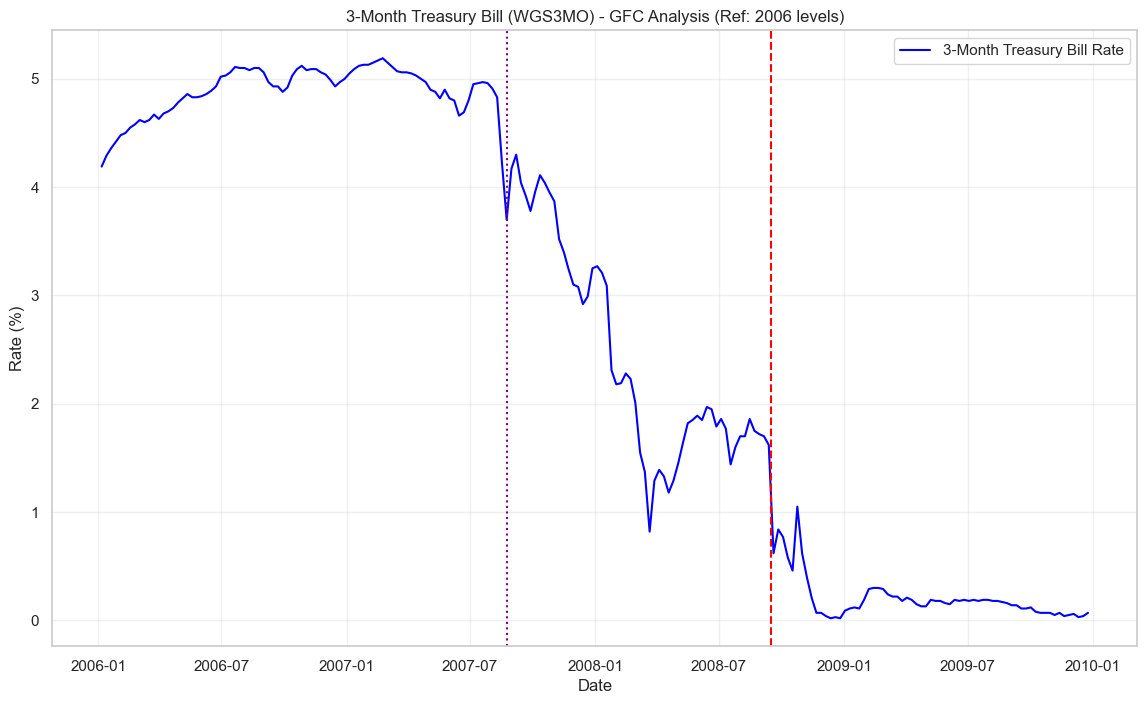

In [4]:
# 1. Load and Filter Treasury Data for 2006-2009
df_wgs3mo = pd.read_csv('../data/WGS3MO.csv')
df_wgs3mo['observation_date'] = pd.to_datetime(df_wgs3mo['observation_date'])
df_wgs3mo = df_wgs3mo[(df_wgs3mo['observation_date'] >= '2006-01-01') & (df_wgs3mo['observation_date'] <= '2009-12-31')]

# 2. Plotting
plt.figure(figsize=(14, 8))
plt.plot(df_wgs3mo['observation_date'], df_wgs3mo['WGS3MO'], color='blue', label='3-Month Treasury Bill Rate')

# Vertical line for Lehman Collapse
plt.axvline(pd.to_datetime('2008-09-15'), color='red', linestyle='--')

# Vertical line for Rate Reversal below 2006 levels (Aug 24, 2007)
plt.axvline(pd.to_datetime('2007-08-24'), color='purple', linestyle=':')

plt.title('3-Month Treasury Bill (WGS3MO) - GFC Analysis (Ref: 2006 levels)')
plt.ylabel('Rate (%)')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Slide 6: Who Bears the Losses

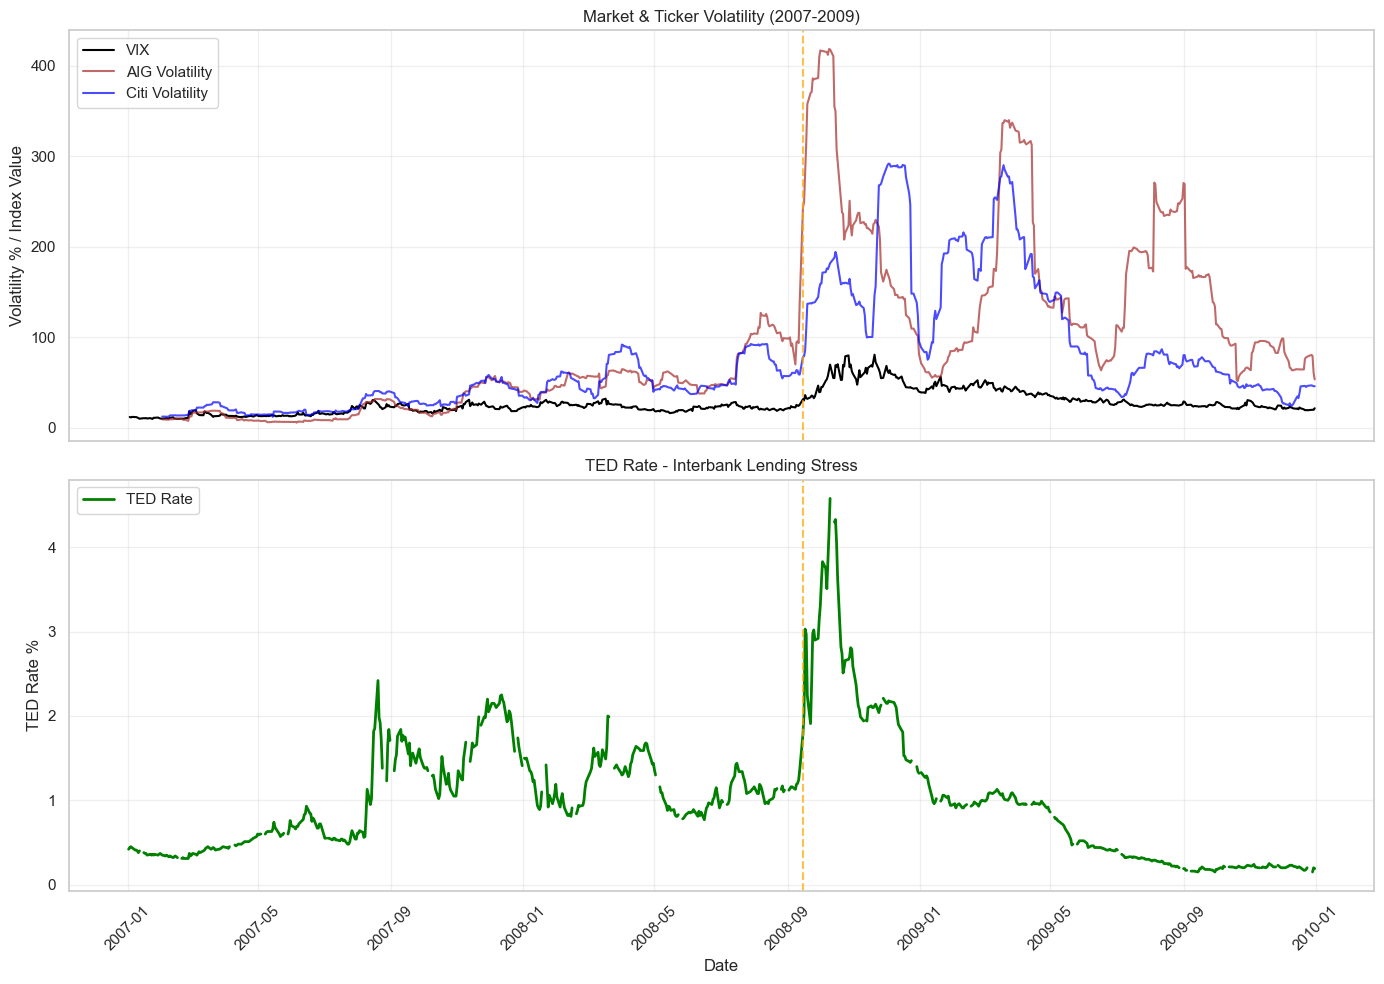

In [5]:
def load_and_prep(path, name, date_col='Date', price_col='Close'):
    # Skip the first 3 messy header rows and use 6 explicit column names
    df = pd.read_csv(path, skiprows=3, header=None)
    df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
    
    df['Date'] = pd.to_datetime(df['Date'])
    df = df[(df['Date'] >= '2007-01-01') & (df['Date'] <= '2009-12-31')]
    df = df.sort_values('Date')
    
    # Calculate 30-day rolling volatility (annualized)
    df['Returns'] = df[price_col].pct_change()
    df['Volatility'] = df['Returns'].rolling(window=21).std() * np.sqrt(252) * 100
    return df[['Date', 'Volatility']].dropna()

# 1. Load Data
# VIX has the same 6-column structure as AIG/C
df_vix_raw = pd.read_csv('../data/^VIX.csv', skiprows=3, header=None)
df_vix_raw.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df_vix_raw['Date'] = pd.to_datetime(df_vix_raw['Date'])
df_vix = df_vix_raw[(df_vix_raw['Date'] >= '2007-01-01') & (df_vix_raw['Date'] <= '2009-12-31')]

df_aig = load_and_prep('../data/AIG.csv', 'AIG')
df_c = load_and_prep('../data/C.csv', 'Citi')

df_ted = pd.read_csv('../data/TEDRATE.csv')
df_ted['observation_date'] = pd.to_datetime(df_ted['observation_date'])
df_ted = df_ted[(df_ted['observation_date'] >= '2007-01-01') & (df_ted['observation_date'] <= '2009-12-31')]
df_ted['TEDRATE'] = pd.to_numeric(df_ted['TEDRATE'], errors='coerce')

# 2. Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Subplot 1: Volatility
ax1.plot(df_vix['Date'], df_vix['Close'], label='VIX', color='black', linewidth=1.5)
ax1.plot(df_aig['Date'], df_aig['Volatility'], label='AIG Volatility', color='brown', alpha=0.7)
ax1.plot(df_c['Date'], df_c['Volatility'], label='Citi Volatility', color='blue', alpha=0.7)
ax1.set_ylabel('Volatility % / Index Value')
ax1.set_title('Market & Ticker Volatility (2007-2009)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Subplot 2: TED Rate
ax2.plot(df_ted['observation_date'], df_ted['TEDRATE'], label='TED Rate', color='green', linewidth=2)
ax2.set_ylabel('TED Rate %')
ax2.set_xlabel('Date')
ax2.set_title('TED Rate - Interbank Lending Stress')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Mark Lehman Collapse
lehman_date = pd.to_datetime('2008-09-15')
ax1.axvline(lehman_date, color='orange', linestyle='--', alpha=0.7, label='Lehman Collapse')
ax2.axvline(lehman_date, color='orange', linestyle='--', alpha=0.7, label='Lehman Collapse')

plt.xticks(rotation=45)
fig.tight_layout()
plt.show()